## Importing Libraries

In [2]:
#!pip install river
!pip install scikit-learn lightgbm imbalanced-learn

import numpy as np
import random
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set all random seeds for reproducibility
np.random.seed(42)
random.seed(42)
os.environ['PYTHONHASHSEED'] = '42'

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder
from scipy.stats import shapiro
#from river import ensemble, tree, drift, stream

# Dataset Import

In [4]:
from google.colab import files
uploaded = files.upload()  # upload IoT_2020_b_0.01.csv

Saving IoT_2020_b_0.01.csv to IoT_2020_b_0.01 (1).csv


#AutoML Framework

In [5]:
def Auto_Encoding(df):
    cat_features=[x for x in df.columns if df[x].dtype=="object"]
    le=LabelEncoder()
    for col in cat_features:
        if col in df.columns:
            df[col] = le.fit_transform(df[col].astype(str))
    return df

def Auto_Imputation(df):
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.fillna(0, inplace=True)
    return df

def Auto_Normalization(df, label):
    stat, p = shapiro(df.select_dtypes(include=[np.number]))
    print('Statistics=%.3f, p=%.3f' % (stat, p))
    alpha = 0.05
    numeric_features = [c for c in df.columns if df[c].dtype != 'object' and c != label]
    if p > alpha:
        print('Sample looks Gaussian (fail to reject H0)')
        df[numeric_features] = (df[numeric_features] - df[numeric_features].mean()) / (df[numeric_features].std())
    else:
        print('Sample does not look Gaussian (reject H0)')
        df[numeric_features] = (df[numeric_features] - df[numeric_features].min()) / (df[numeric_features].max()-df[numeric_features].min())
    return df

def Feature_Importance_IG(data, label_col):
    features = data.drop([label_col],axis=1).values
    labels = data[label_col].values
    feature_names = list(data.drop([label_col],axis=1).columns)
    model = lgb.LGBMRegressor(verbose = -1)
    model.fit(features, labels)
    feature_importances = pd.DataFrame({'feature': feature_names, 'importance': model.feature_importances_})
    feature_importances['normalized_importance'] = feature_importances['importance'] / feature_importances['importance'].sum()
    feature_importances['cumulative_importance'] = np.cumsum(feature_importances['normalized_importance'])
    cumulative_importance=0.90
    record_low_importance = feature_importances[feature_importances['cumulative_importance'] > cumulative_importance]
    to_drop = list(record_low_importance['feature'])
    return to_drop

def Feature_Redundancy_Pearson(data, label_col):
    correlation_threshold=0.90
    features = data.drop([label_col],axis=1)
    corr_matrix = features.corr()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k = 1).astype(bool))
    to_drop = [column for column in upper.columns if any(upper[column].abs() > correlation_threshold)]
    return to_drop

def Auto_Feature_Engineering(df, label_col):
    drop1 = Feature_Importance_IG(df, label_col)
    df1 = df.drop(columns=[c for c in drop1 if c in df.columns])
    drop2 = Feature_Redundancy_Pearson(df1, label_col)
    df2 = df1.drop(columns=[c for c in drop2 if c in df1.columns])
    if label_col not in df2.columns and label_col in df.columns:
        df2[label_col] = df[label_col]
    return df2

# Imports and Classifier Setup

In [6]:
!pip install river==0.11.1
from river import ensemble, tree, drift, stream
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from river import ensemble, tree, drift, stream
from river.drift import DDM, ADWIN, EDDM


# Classifier list as requested
from river.tree import HoeffdingTreeClassifier, HoeffdingAdaptiveTreeClassifier
from river.ensemble import LeveragingBaggingClassifier, SRPClassifier
try:
    from river.tree.mondrian import MondrianTreeClassifier
except ImportError:
    MondrianTreeClassifier = None

CLASSIFIERS = [
    ('HoeffdingTree', HoeffdingTreeClassifier),
    ('LeveragingBagging', lambda: LeveragingBaggingClassifier(model=HoeffdingTreeClassifier())),
    ('SRPClassifier', lambda: SRPClassifier(n_models=3)),
    ('HoeffdingAdaptiveTree', HoeffdingAdaptiveTreeClassifier)
]
if hasattr(ensemble, 'AdaptiveRandomForestClassifier'):
    CLASSIFIERS.append(('AdaptiveRandomForest', lambda: ensemble.AdaptiveRandomForestClassifier(n_models=3)))
if MondrianTreeClassifier:
    CLASSIFIERS.append(('MondrianTree', MondrianTreeClassifier))

def label_flip(xi, yi, classes):
    import random
    return xi, random.choice([c for c in classes if c != yi])

def noise_injection(xi, yi, feature_ranges):
    import copy
    xi_ = copy.deepcopy(xi)
    for k, (low, high) in feature_ranges.items():
        try:
            noise = np.random.uniform(-0.1, 0.1) * (high - low)
            xi_[k] = np.clip(xi_[k] + noise, low, high)
        except:
            pass
    return xi_, yi

POISONING_RATES = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
POISONING_TYPES = ["label_flip", "noise_injection"]

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.1/849.1 kB 9.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for river: filename=river-0.11.1-cp313-cp313-linux_x86_64.whl size=2154718 sha256=5e43dcf30d9af47bfbd6b4547f960a083e8aef7045460eaaab0c3c4e89c3f3e9
  Stored in directory: /root/.cache/pip/wheels/29/94/f8/04a3b89d917421a6630bb13a163f820a561772d423afface5f
Successfully built river


In [7]:
df = pd.read_csv("IoT_2020_b_0.01.csv")
label_col = "Label"
df = Auto_Encoding(df)
df = Auto_Imputation(df)
df = Auto_Normalization(df, label_col)
df = Auto_Feature_Engineering(df, label_col)

X = df.drop([label_col], axis=1)
y = df[label_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.01, shuffle=False, random_state=42)
classes = list(set(y_train) | set(y_test))
feature_ranges = {col: (X_train[col].min(), X_train[col].max()) for col in X_train.columns}

all_results = []

for clf_name, clf_class in CLASSIFIERS:
    for poison_type in POISONING_TYPES:
        for rate in POISONING_RATES:
            print(f"\n[{clf_name}] Poison: {poison_type} Rate: {rate:.2f}")
            if poison_type == "label_flip":
                poison_fn = lambda xi, yi: label_flip(xi, yi, classes)
            elif poison_type == "noise_injection":
                poison_fn = lambda xi, yi: noise_injection(xi, yi, feature_ranges)
            else:
                poison_fn = lambda xi, yi: (xi, yi)

            # NAIVE
            model = clf_class()
            yt, yp = [], []
            poisoned_indices = []
            for i, (xi, yi) in enumerate(stream.iter_pandas(X_train, y_train)):
                dict_xi = dict(xi)
                if np.random.rand() < rate:
                    dict_xi, yi = poison_fn(dict_xi, yi)
                    poisoned_indices.append(i)
                model.learn_one(dict_xi, yi)
            for xi, yi in stream.iter_pandas(X_test, y_test):
                pred = model.predict_one(dict(xi))
                yt.append(yi)
                yp.append(pred)
            acc = accuracy_score(yt, yp)
            f1 = f1_score(yt, yp, average='weighted', zero_division=0)
            pre = precision_score(yt, yp, average='weighted', zero_division=0)
            rec = recall_score(yt, yp, average='weighted', zero_division=0)
            print(f"    [Naive ] Acc: {acc:.3f} F1: {f1:.3f} Prec: {pre:.3f} Rec: {rec:.3f}")

            # ADVERSARIAL
            model_adv = clf_class()
            yt_adv, yp_adv = [], []
            for i, (xi, yi) in enumerate(stream.iter_pandas(X_train, y_train)):
                dict_xi = dict(xi)
                if np.random.rand() < rate:
                    dict_xi, yi = poison_fn(dict_xi, yi)
                model_adv.learn_one(dict_xi, yi)
                xi_adv, yi_adv = poison_fn(dict_xi, yi)
                model_adv.learn_one(xi_adv, yi_adv)
            for xi, yi in stream.iter_pandas(X_test, y_test):
                pred = model_adv.predict_one(dict(xi))
                yt_adv.append(yi)
                yp_adv.append(pred)
            acc_adv = accuracy_score(yt_adv, yp_adv)
            f1_adv = f1_score(yt_adv, yp_adv, average='weighted', zero_division=0)
            pre_adv = precision_score(yt_adv, yp_adv, average='weighted', zero_division=0)
            rec_adv = recall_score(yt_adv, yp_adv, average='weighted', zero_division=0)
            print(f"    [AdvTrn] Acc: {acc_adv:.3f} F1: {f1_adv:.3f} Prec: {pre_adv:.3f} Rec: {rec_adv:.3f}")

            # DRIFT DETECTION
            from river.drift import DDM, ADWIN, EDDM
            detectors = {
                "DDM": DDM(),
                "ADWIN": ADWIN(),
                "EDDM": EDDM()
            }
            drift_events = {name: [] for name in detectors}
            for ndx, (ytrue, ypred) in enumerate(zip(yt, yp)):
                correct = int(ytrue == ypred)
                for name, det in detectors.items():
                    out = det.update(correct)
                    in_drift = out[0] if isinstance(out, tuple) else out
                    if in_drift:
                        drift_events[name].append(ndx)

            detectors_adv = {
                "DDM": DDM(),
                "ADWIN": ADWIN(),
                "EDDM": EDDM()
            }
            drift_events_adv = {name: [] for name in detectors_adv}
            for ndx, (ytrue, ypred) in enumerate(zip(yt_adv, yp_adv)):
                correct = int(ytrue == ypred)
                for name, det in detectors_adv.items():
                    out = det.update(correct)
                    in_drift = out[0] if isinstance(out, tuple) else out
                    if in_drift:
                        drift_events_adv[name].append(ndx)

            # PRINT DRIFT SUMMARY
            print(
                f"   [Drifts] NAIVE -- EDDM: {len(drift_events['EDDM'])}, "
                f"DDM: {len(drift_events['DDM'])}, ADWIN: {len(drift_events['ADWIN'])} "
                f"(overlap with poison: "
                f"EDDM {len(set(drift_events['EDDM']) & set(poisoned_indices))}, "
                f"DDM {len(set(drift_events['DDM']) & set(poisoned_indices))}, "
                f"ADWIN {len(set(drift_events['ADWIN']) & set(poisoned_indices))})"
            )
            print(
                f"   [Drifts] ADVTRN -- EDDM: {len(drift_events_adv['EDDM'])}, "
                f"DDM: {len(drift_events_adv['DDM'])}, ADWIN: {len(drift_events_adv['ADWIN'])} "
                f"(overlap with poison: "
                f"EDDM {len(set(drift_events_adv['EDDM']) & set(poisoned_indices))}, "
                f"DDM {len(set(drift_events_adv['DDM']) & set(poisoned_indices))}, "
                f"ADWIN {len(set(drift_events_adv['ADWIN']) & set(poisoned_indices))})"
            )

            all_results.append({
                "dataset": "IoT_2020_b_0.01.csv",
                "classifier": clf_name,
                "poison_type": poison_type,
                "rate": rate,
                "naive_acc": acc, "naive_f1": f1, "naive_pre": pre, "naive_rec": rec,
                "at_acc": acc_adv, "at_f1": f1_adv, "at_pre": pre_adv, "at_rec": rec_adv,
                "naive_drift_EDDM": str(drift_events.get('EDDM', [])),
                "naive_drift_DDM": str(drift_events.get('DDM', [])),
                "naive_drift_ADWIN": str(drift_events.get('ADWIN', [])),
                "at_drift_EDDM": str(drift_events_adv.get('EDDM', [])),
                "at_drift_DDM": str(drift_events_adv.get('DDM', [])),
                "at_drift_ADWIN": str(drift_events_adv.get('ADWIN', [])),
                "poisoned_indices": str(list(poisoned_indices)),
                "naive_true": str(list(yt)),
                "naive_pred": str(list(yp)),
                "at_true": str(list(yt_adv)),
                "at_pred": str(list(yp_adv)),
            })

# Save all results at the end
df_results = pd.DataFrame(all_results)
df_results.to_csv('sweep_results.csv', index=False)
print("Results saved to sweep_results.csv")

# Now you can continue with plotting and table code as before!

/usr/local/lib/python3.13/dist-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 200064.
  res = hypotest_fun_out(*samples, **kwds)


Statistics=0.108, p=0.000
Sample does not look Gaussian (reject H0)

[HoeffdingTree] Poison: label_flip Rate: 0.00
    [Naive ] Acc: 0.942 F1: 0.914 Prec: 0.888 Rec: 0.942
    [AdvTrn] Acc: 0.058 F1: 0.006 Prec: 0.003 Rec: 0.058
   [Drifts] NAIVE -- EDDM: 13, DDM: 0, ADWIN: 0 (overlap with poison: EDDM 0, DDM 0, ADWIN 0)
   [Drifts] ADVTRN -- EDDM: 10, DDM: 0, ADWIN: 0 (overlap with poison: EDDM 0, DDM 0, ADWIN 0)

[HoeffdingTree] Poison: label_flip Rate: 0.20
    [Naive ] Acc: 0.942 F1: 0.914 Prec: 0.888 Rec: 0.942
    [AdvTrn] Acc: 0.058 F1: 0.006 Prec: 0.003 Rec: 0.058
   [Drifts] NAIVE -- EDDM: 13, DDM: 0, ADWIN: 0 (overlap with poison: EDDM 0, DDM 0, ADWIN 0)
   [Drifts] ADVTRN -- EDDM: 10, DDM: 0, ADWIN: 0 (overlap with poison: EDDM 0, DDM 0, ADWIN 0)

[HoeffdingTree] Poison: label_flip Rate: 0.40
    [Naive ] Acc: 0.942 F1: 0.914 Prec: 0.888 Rec: 0.942
    [AdvTrn] Acc: 0.058 F1: 0.006 Prec: 0.003 Rec: 0.058
   [Drifts] NAIVE -- EDDM: 13, DDM: 0, ADWIN: 0 (overlap with poison: E

# Tables and Plots

In [8]:
#Metrics Table (LaTeX/Markdown for Paper)
import pandas as pd
rates_select = [0.0, 0.4, 1.0]
table_metrics = df_results[df_results['rate'].isin(rates_select)]
cols = [
    'classifier', 'poison_type', 'rate',
    'naive_acc', 'naive_f1', 'naive_pre', 'naive_rec',
    'at_acc', 'at_f1', 'at_pre', 'at_rec'
]
table_to_show = table_metrics[cols]
print(table_to_show.to_latex(index=False, float_format="%.3f"))   # For LaTeX (Overleaf)
print(table_to_show.to_markdown(index=False, floatfmt=".3f"))     # For Word/Markdown/Excel

\begin{tabular}{llrrrrrrrrr}
\toprule
classifier & poison_type & rate & naive_acc & naive_f1 & naive_pre & naive_rec & at_acc & at_f1 & at_pre & at_rec \\
\midrule
HoeffdingTree & label_flip & 0.000 & 0.942 & 0.914 & 0.888 & 0.942 & 0.058 & 0.006 & 0.003 & 0.058 \\
HoeffdingTree & label_flip & 0.400 & 0.942 & 0.914 & 0.888 & 0.942 & 0.058 & 0.006 & 0.003 & 0.058 \\
HoeffdingTree & label_flip & 1.000 & 0.058 & 0.006 & 0.003 & 0.058 & 0.058 & 0.006 & 0.003 & 0.058 \\
HoeffdingTree & noise_injection & 0.000 & 0.942 & 0.914 & 0.888 & 0.942 & 0.686 & 0.769 & 0.907 & 0.686 \\
HoeffdingTree & noise_injection & 0.400 & 0.905 & 0.922 & 0.951 & 0.905 & 0.718 & 0.791 & 0.905 & 0.718 \\
HoeffdingTree & noise_injection & 1.000 & 0.942 & 0.914 & 0.888 & 0.942 & 0.721 & 0.793 & 0.905 & 0.721 \\
LeveragingBagging & label_flip & 0.000 & 0.898 & 0.911 & 0.928 & 0.898 & 0.429 & 0.550 & 0.905 & 0.429 \\
LeveragingBagging & label_flip & 0.400 & 0.191 & 0.259 & 0.857 & 0.191 & 0.296 & 0.409 & 0.860 & 0.296 

In [9]:
# Drift Count Table (LaTeX/Markdown)
import ast
drift_table = []
for _, row in df_results[df_results['rate'].isin(rates_select)].iterrows():
    drift_table.append({
        'Classifier': row['classifier'],
        'Attack': row['poison_type'],
        'Rate': row['rate'],
        'Naive-EDDM': len(ast.literal_eval(row['naive_drift_EDDM'])),
        'Naive-DDM': len(ast.literal_eval(row['naive_drift_DDM'])),
        'Naive-ADWIN': len(ast.literal_eval(row['naive_drift_ADWIN'])),
        'AT-EDDM': len(ast.literal_eval(row['at_drift_EDDM'])),
        'AT-DDM': len(ast.literal_eval(row['at_drift_DDM'])),
        'AT-ADWIN': len(ast.literal_eval(row['at_drift_ADWIN'])),
    })
drift_df = pd.DataFrame(drift_table)
print(drift_df.to_latex(index=False))
print(drift_df.to_markdown(index=False))

\begin{tabular}{llrrrrrrr}
\toprule
Classifier & Attack & Rate & Naive-EDDM & Naive-DDM & Naive-ADWIN & AT-EDDM & AT-DDM & AT-ADWIN \\
\midrule
HoeffdingTree & label_flip & 0.000000 & 13 & 0 & 0 & 10 & 0 & 0 \\
HoeffdingTree & label_flip & 0.400000 & 13 & 0 & 0 & 10 & 0 & 0 \\
HoeffdingTree & label_flip & 1.000000 & 10 & 0 & 0 & 10 & 0 & 0 \\
HoeffdingTree & noise_injection & 0.000000 & 13 & 0 & 0 & 6 & 0 & 0 \\
HoeffdingTree & noise_injection & 0.400000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & noise_injection & 1.000000 & 13 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & label_flip & 0.000000 & 0 & 0 & 0 & 1 & 0 & 0 \\
LeveragingBagging & label_flip & 0.400000 & 15 & 0 & 0 & 9 & 0 & 0 \\
LeveragingBagging & label_flip & 1.000000 & 10 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & noise_injection & 0.000000 & 0 & 0 & 0 & 3 & 0 & 0 \\
LeveragingBagging & noise_injection & 0.400000 & 24 & 0 & 0 & 2 & 0 & 0 \\
LeveragingBagging & noise_injection & 1.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
SRPClassifi

In [10]:
# Drift-Poison Overlap Table (LaTeX/Markdown)
overlap_table = []
for _, row in df_results[df_results['rate'].isin(rates_select)].iterrows():
    poison_ids = set(ast.literal_eval(row['poisoned_indices']))
    overlap_table.append({
        'Classifier': row['classifier'],
        'Attack': row['poison_type'],
        'Rate': row['rate'],
        'Naive-EDDM': len(set(ast.literal_eval(row['naive_drift_EDDM'])) & poison_ids),
        'Naive-DDM': len(set(ast.literal_eval(row['naive_drift_DDM'])) & poison_ids),
        'Naive-ADWIN': len(set(ast.literal_eval(row['naive_drift_ADWIN'])) & poison_ids),
        'AT-EDDM': len(set(ast.literal_eval(row['at_drift_EDDM'])) & poison_ids),
        'AT-DDM': len(set(ast.literal_eval(row['at_drift_DDM'])) & poison_ids),
        'AT-ADWIN': len(set(ast.literal_eval(row['at_drift_ADWIN'])) & poison_ids),
    })
overlap_df = pd.DataFrame(overlap_table)
print(overlap_df.to_latex(index=False))
print(overlap_df.to_markdown(index=False))

\begin{tabular}{llrrrrrrr}
\toprule
Classifier & Attack & Rate & Naive-EDDM & Naive-DDM & Naive-ADWIN & AT-EDDM & AT-DDM & AT-ADWIN \\
\midrule
HoeffdingTree & label_flip & 0.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & label_flip & 0.400000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & label_flip & 1.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & noise_injection & 0.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & noise_injection & 0.400000 & 0 & 0 & 0 & 0 & 0 & 0 \\
HoeffdingTree & noise_injection & 1.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & label_flip & 0.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & label_flip & 0.400000 & 0 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & label_flip & 1.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & noise_injection & 0.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
LeveragingBagging & noise_injection & 0.400000 & 1 & 0 & 0 & 1 & 0 & 0 \\
LeveragingBagging & noise_injection & 1.000000 & 0 & 0 & 0 & 0 & 0 & 0 \\
SRPClassifier & label_

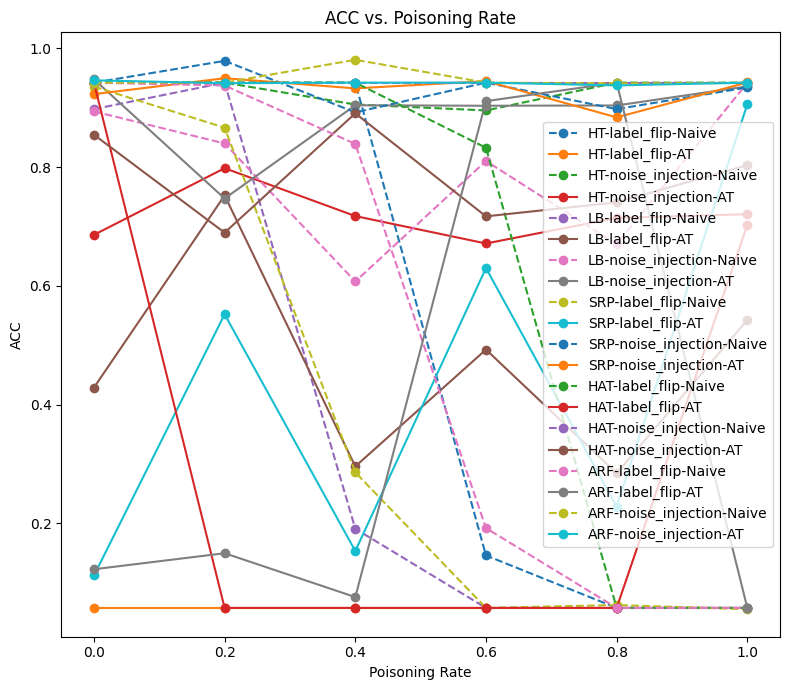

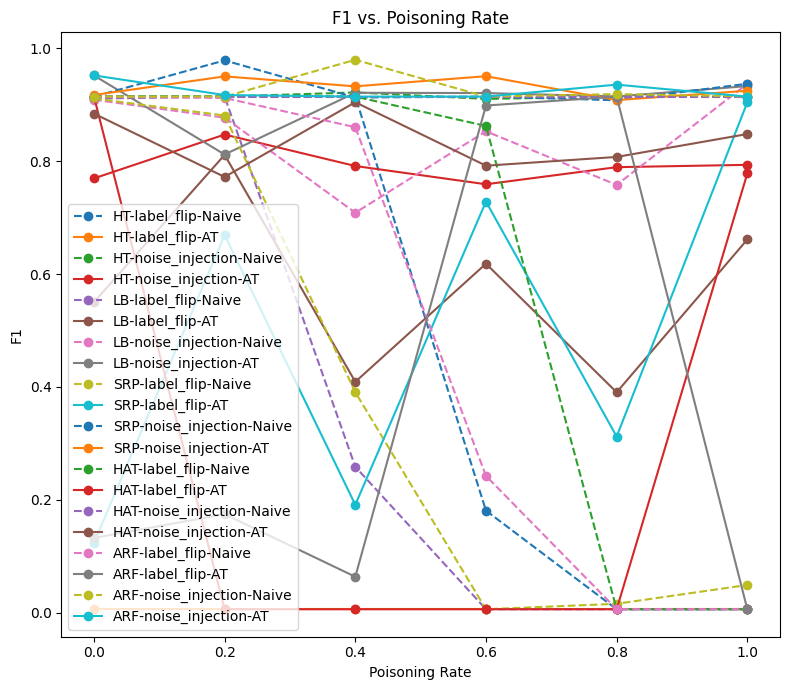

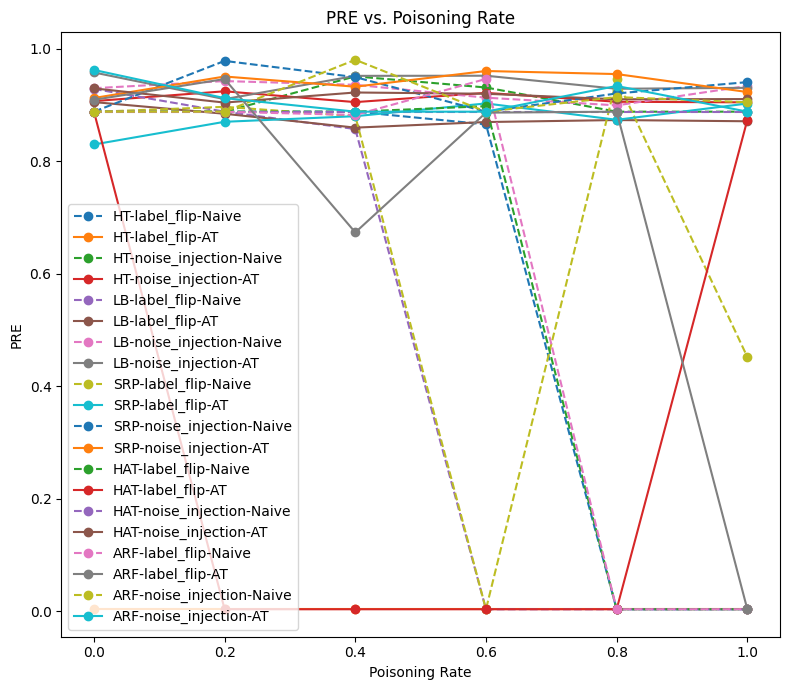

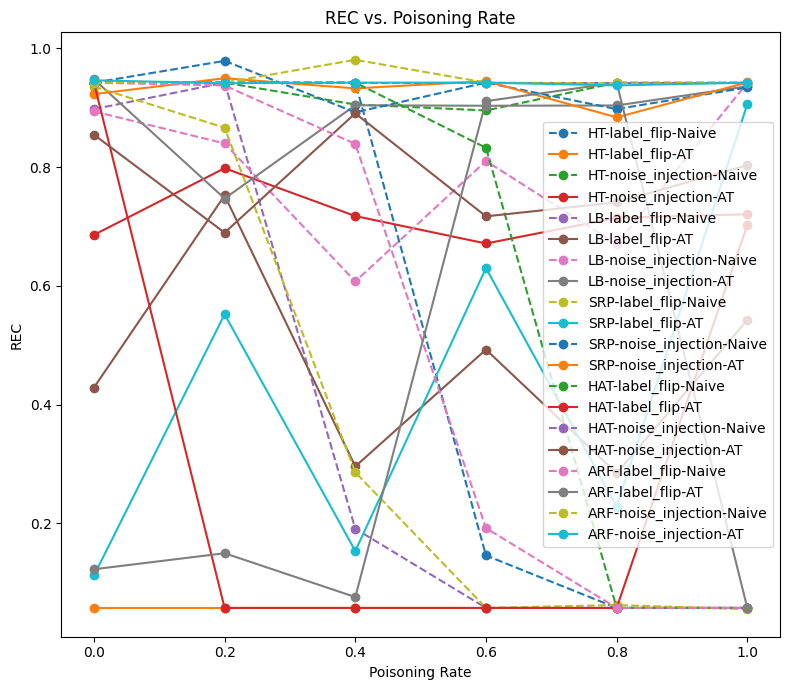

In [11]:
# Metrics Trend Line Plots
clf_abbr = {
    'HoeffdingTree': 'HT',
    'HoeffdingAdaptiveTree': 'HAT',
    'AdaptiveRandomForest': 'ARF',
    'SRPClassifier': 'SRP',
    'LeveragingBagging': 'LB',
    'MondrianTree': 'MT',
    'label_flip': 'LP',
    'noise_injection': 'MT'
}

import matplotlib.pyplot as plt

metrics = ['acc', 'f1', 'pre', 'rec']
for metric in metrics:
    plt.figure(figsize=(8,7))
    for clf_name in df_results['classifier'].unique():
        clf_short = clf_abbr.get(clf_name, clf_name)
        for pt in df_results['poison_type'].unique():
            dfsub = df_results[(df_results['poison_type']==pt) & (df_results['classifier']==clf_name)]
            plt.plot(dfsub['rate'], dfsub['naive_'+metric], 'o--', label=f"{clf_short}-{pt}-Naive")
            plt.plot(dfsub['rate'], dfsub['at_'+metric], 'o-', label=f"{clf_short}-{pt}-AT" )
    plt.title(f"{metric.upper()} vs. Poisoning Rate")
    plt.xlabel("Poisoning Rate")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()

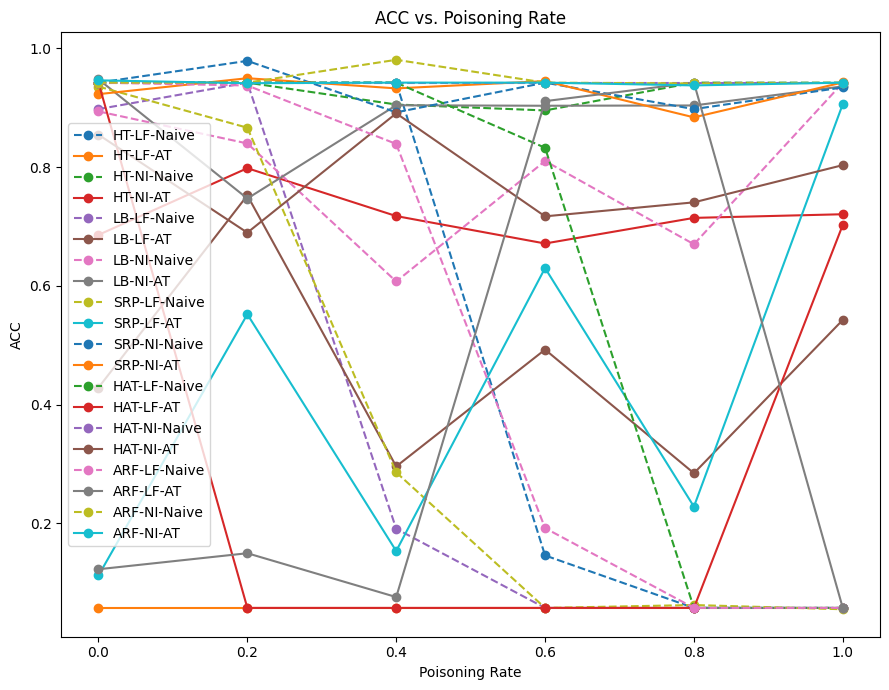

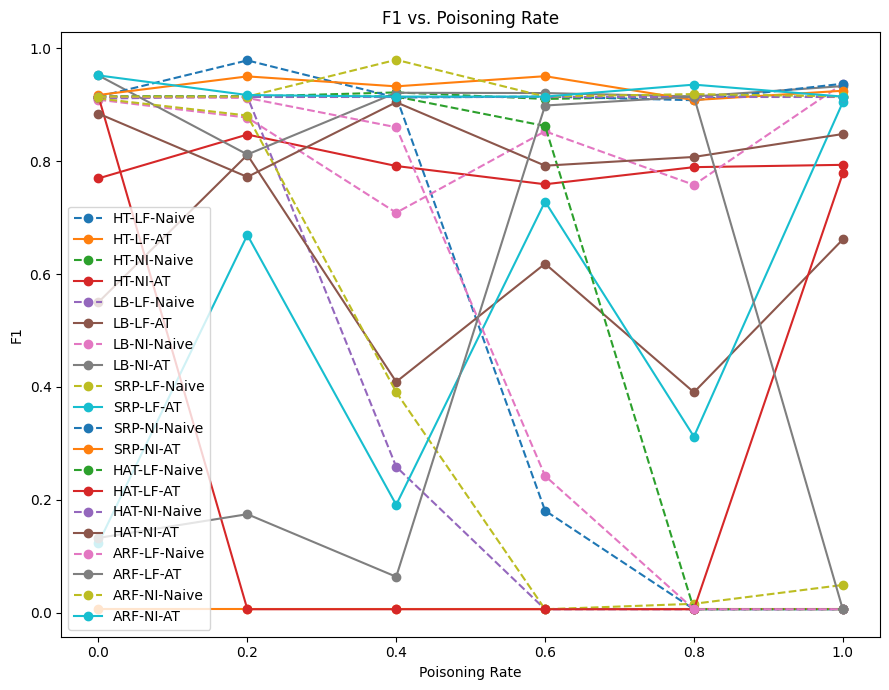

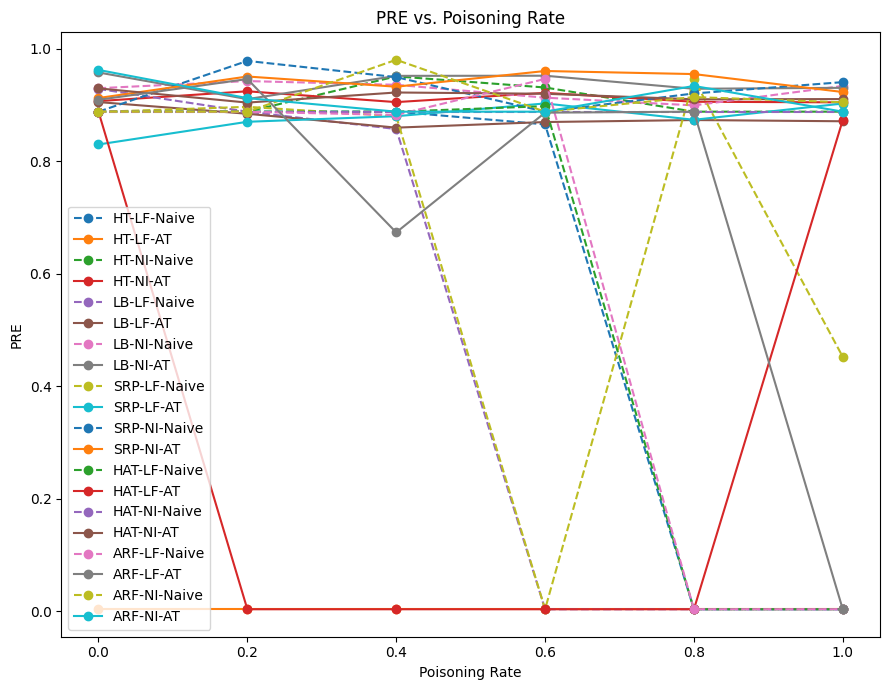

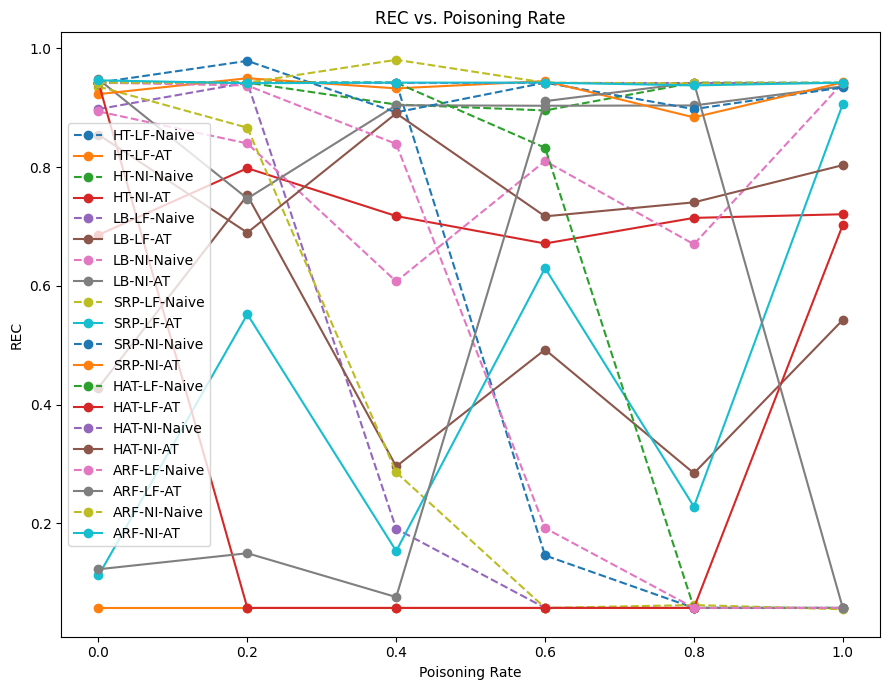

In [24]:
clf_abbr = {
    'HoeffdingTree': 'HT',
    'HoeffdingAdaptiveTree': 'HAT',
    'AdaptiveRandomForest': 'ARF',
    'SRPClassifier': 'SRP',
    'LeveragingBagging': 'LB',
    'MondrianTree': 'MT',
    'label_flip': 'LF',
    'noise_injection': 'NI'
}

import matplotlib.pyplot as plt

metrics = ['acc', 'f1', 'pre', 'rec']
for metric in metrics:
    plt.figure(figsize=(9,7))
    for clf_name in df_results['classifier'].unique():
        clf_short = clf_abbr.get(clf_name, clf_name)
        for pt in df_results['poison_type'].unique():
            pt_short = clf_abbr.get(pt, pt)
            dfsub = df_results[(df_results['poison_type']==pt) & (df_results['classifier']==clf_name)]
            plt.plot(dfsub['rate'], dfsub['naive_'+metric], 'o--', label=f"{clf_short}-{pt_short}-Naive")
            plt.plot(dfsub['rate'], dfsub['at_'+metric], 'o-', label=f"{clf_short}-{pt_short}-AT" )
    plt.title(f"{metric.upper()} vs. Poisoning Rate")
    plt.xlabel("Poisoning Rate")
    plt.ylabel(metric.upper())
    plt.legend()
    plt.tight_layout()
    plt.show()

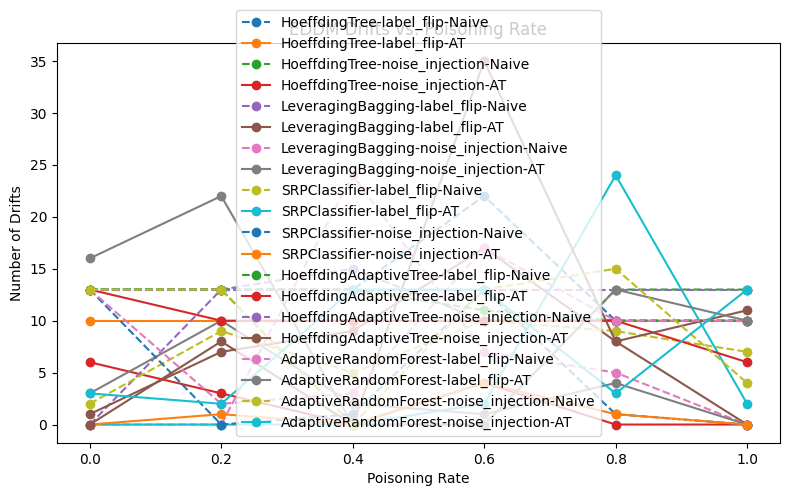

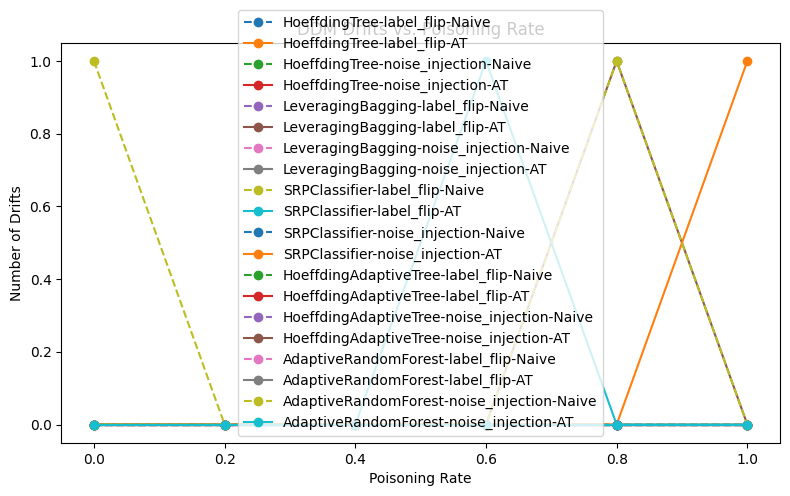

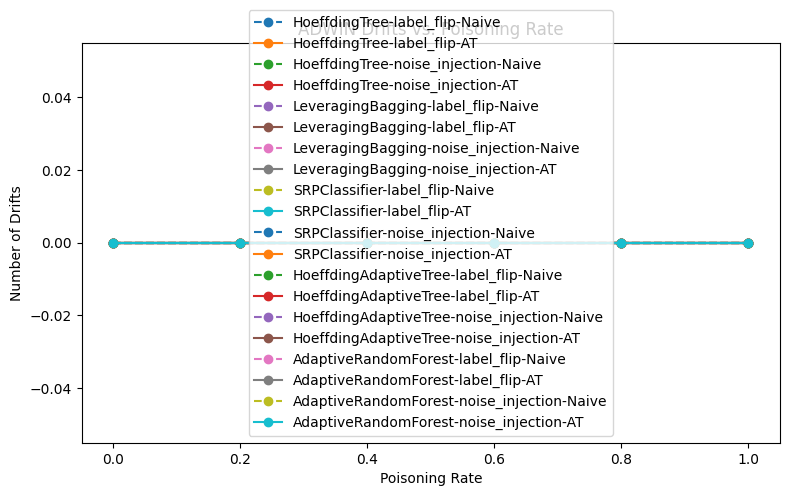

In [13]:
# Drift Method Line Plots (EDDM, DDM, ADWIN)
for driftname in ['EDDM', 'DDM', 'ADWIN']:
    plt.figure(figsize=(8,5))
    for clf_name in df_results['classifier'].unique():
        for pt in df_results['poison_type'].unique():
            dfsub = df_results[(df_results['classifier'] == clf_name) & (df_results['poison_type'] == pt)]
            naive_counts = dfsub['naive_drift_'+driftname].apply(lambda x: len(ast.literal_eval(x)))
            at_counts = dfsub['at_drift_'+driftname].apply(lambda x: len(ast.literal_eval(x)))
            plt.plot(dfsub['rate'], naive_counts, 'o--', label=f"{clf_name}-{pt}-Naive")
            plt.plot(dfsub['rate'], at_counts, 'o-', label=f"{clf_name}-{pt}-AT")
    plt.title(f"{driftname} Drifts vs. Poisoning Rate")
    plt.xlabel("Poisoning Rate")
    plt.ylabel("Number of Drifts")
    plt.legend()
    plt.tight_layout()
    plt.show()

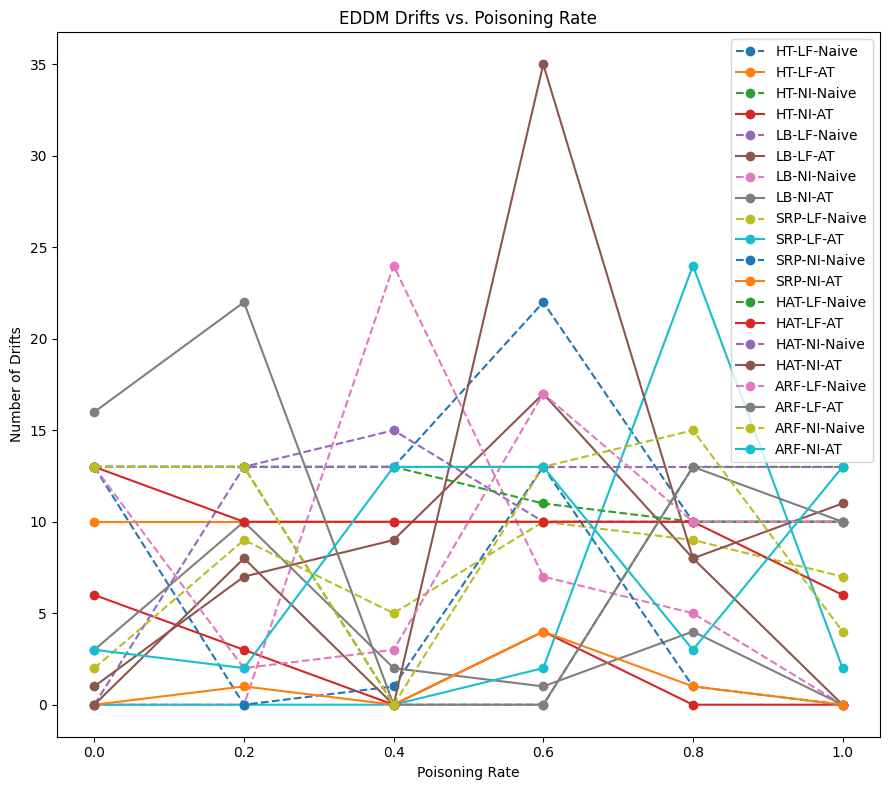

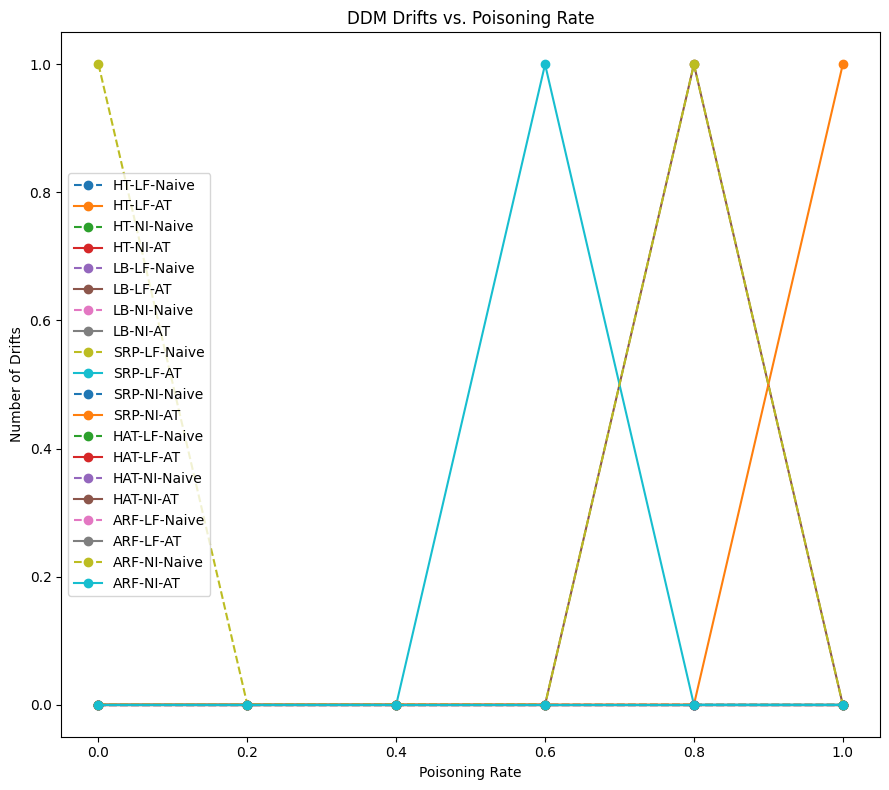

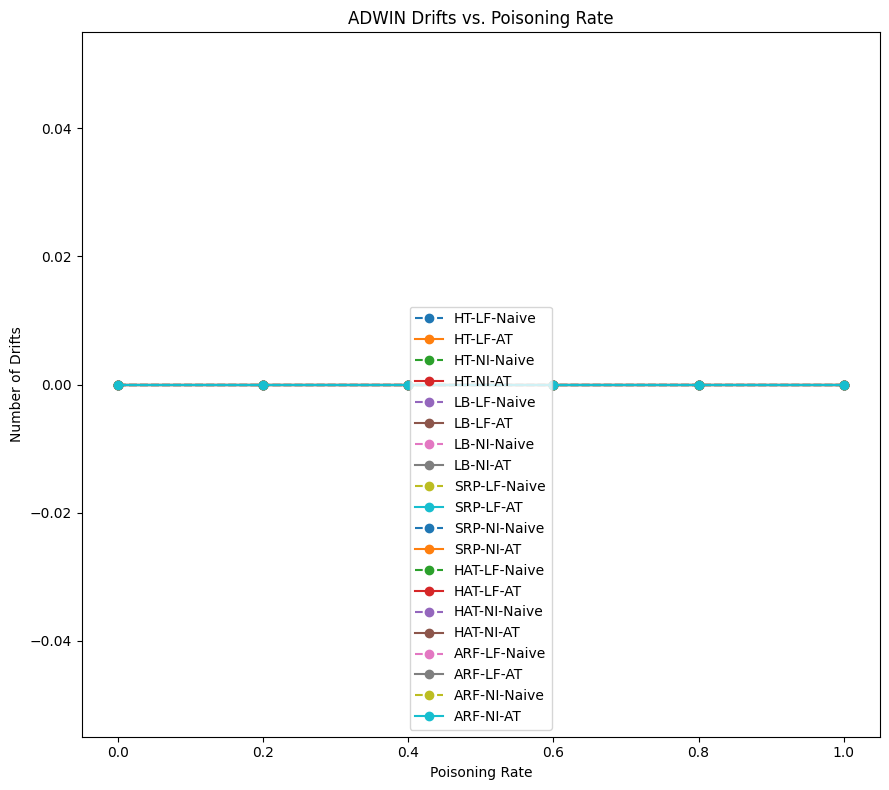

In [23]:
clf_abbr = {
    'HoeffdingTree': 'HT',
    'HoeffdingAdaptiveTree': 'HAT',
    'AdaptiveRandomForest': 'ARF',
    'SRPClassifier': 'SRP',
    'LeveragingBagging': 'LB',
    'MondrianTree': 'MT',
    'label_flip': 'LF',
    'noise_injection': 'NI'
}

import matplotlib.pyplot as plt

for driftname in ['EDDM', 'DDM', 'ADWIN']:
    plt.figure(figsize=(9,8))
    for clf_name in df_results['classifier'].unique():
        clf_short = clf_abbr.get(clf_name, clf_name)
        for pt in df_results['poison_type'].unique():
            pt_short = clf_abbr.get(pt, pt)
            dfsub = df_results[(df_results['classifier'] == clf_name) & (df_results['poison_type'] == pt)]
            naive_counts = dfsub['naive_drift_'+driftname].apply(lambda x: len(ast.literal_eval(x)))
            at_counts = dfsub['at_drift_'+driftname].apply(lambda x: len(ast.literal_eval(x)))
            plt.plot(dfsub['rate'], naive_counts, 'o--', label=f"{clf_short}-{pt_short}-Naive")
            plt.plot(dfsub['rate'], at_counts, 'o-', label=f"{clf_short}-{pt_short}-AT")
    plt.title(f"{driftname} Drifts vs. Poisoning Rate")
    plt.xlabel("Poisoning Rate")
    plt.ylabel("Number of Drifts")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [16]:
# List the columns that correspond to overlaps
overlap_cols = [col for col in overlap_df.columns if col not in ['Classifier', 'Attack', 'Rate']]
# Filter only where any overlap is >0
overlap_subset = overlap_df[(overlap_df[overlap_cols] > 0).any(axis=1)]
print(overlap_subset.to_markdown(index=False))

| Classifier        | Attack          |   Rate |   Naive-EDDM |   Naive-DDM |   Naive-ADWIN |   AT-EDDM |   AT-DDM |   AT-ADWIN |
|:------------------|:----------------|-------:|-------------:|------------:|--------------:|----------:|---------:|-----------:|
| LeveragingBagging | noise_injection |    0.4 |            1 |           0 |             0 |         1 |        0 |          0 |


In [17]:
# (Assume overlap_subset is made as you did)
# Find columns where any value is nonzero (excluding Classifier, Attack, Rate)
cols_to_keep = ['Classifier', 'Attack', 'Rate'] + [
    col for col in overlap_subset.columns
    if col not in ['Classifier', 'Attack', 'Rate'] and (overlap_subset[col] > 0).any()
]
# Filter your DataFrame to only those columns
overlap_final = overlap_subset[cols_to_keep]

print(overlap_final.to_markdown(index=False))
# Or, for LaTeX:
print(overlap_final.to_latex(index=False))

| Classifier        | Attack          |   Rate |   Naive-EDDM |   AT-EDDM |
|:------------------|:----------------|-------:|-------------:|----------:|
| LeveragingBagging | noise_injection |    0.4 |            1 |         1 |
\begin{tabular}{llrrr}
\toprule
Classifier & Attack & Rate & Naive-EDDM & AT-EDDM \\
\midrule
LeveragingBagging & noise_injection & 0.400000 & 1 & 1 \\
\bottomrule
\end{tabular}



In [19]:
overlap_cols = [col for col in overlap_df.columns if col not in ['Classifier', 'Attack', 'Rate']]
# Filter only where at least one overlap (in ANY column) is >0
nonzero_rows = overlap_df.loc[(overlap_df[overlap_cols] > 0).any(axis=1)]
print(nonzero_rows.to_markdown(index=False))

| Classifier        | Attack          |   Rate |   Naive-EDDM |   Naive-DDM |   Naive-ADWIN |   AT-EDDM |   AT-DDM |   AT-ADWIN |
|:------------------|:----------------|-------:|-------------:|------------:|--------------:|----------:|---------:|-----------:|
| LeveragingBagging | noise_injection |    0.4 |            1 |           0 |             0 |         1 |        0 |          0 |


#First RUN

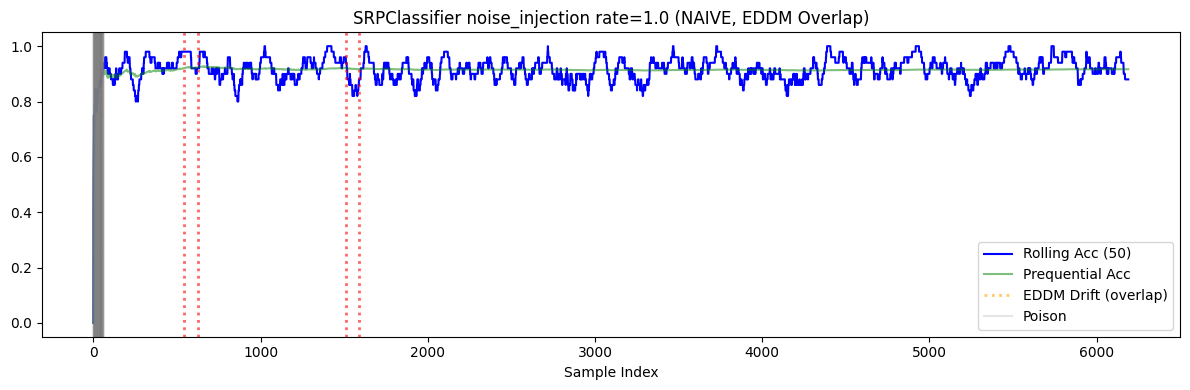

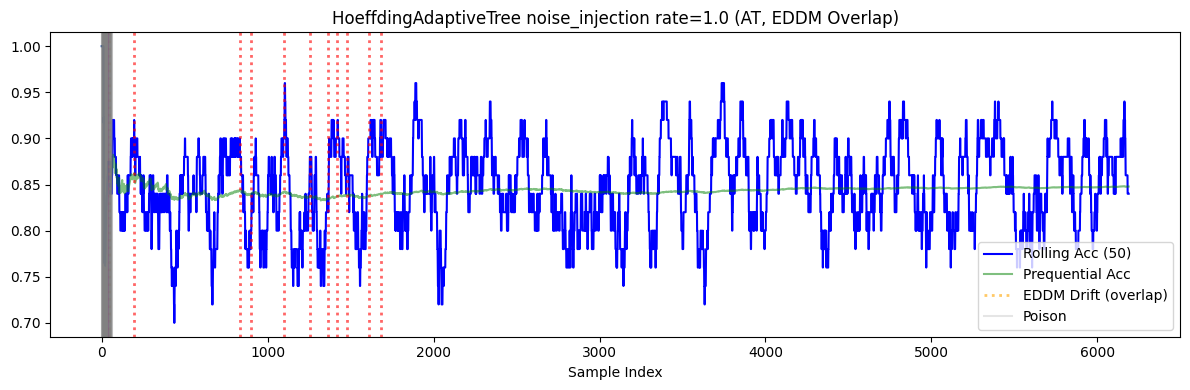

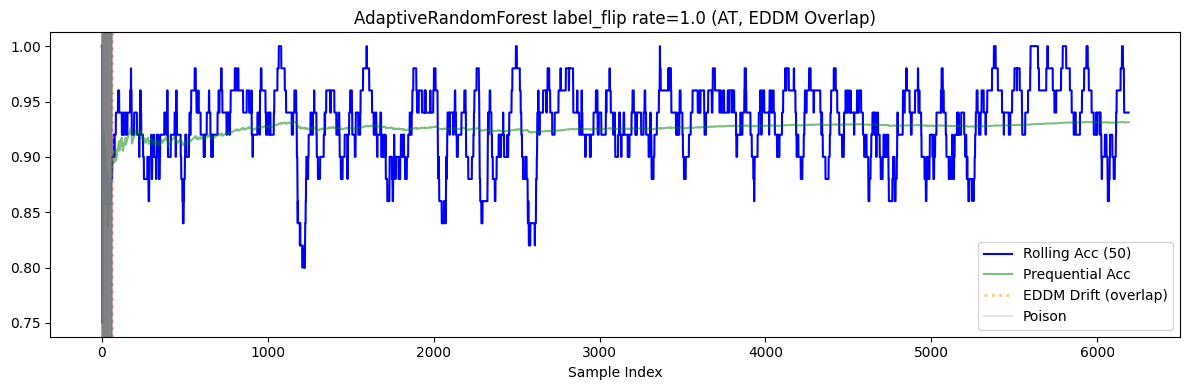

In [25]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def safe_parse_list(s):
    import re
    if type(s) is list:
        return s
    if not isinstance(s, str): return list(s)
    s = re.sub(r'np\.int\d+\((\d+)\)', r'\1', s)
    s = s.replace('\n', ' ').replace('array(', '').replace(')', '')
    try:
        return [int(x.strip()) for x in s.strip('[]').split(',') if x.strip()]
    except Exception:
        import ast; return ast.literal_eval(s)

def plot_temporal_drift_overlap(y_true, y_pred, drift_points, poison_indices, dmethod, title=""):
    correct = [int(yt == yp) for yt, yp in zip(y_true, y_pred)]
    rolling = pd.Series(correct).rolling(50, min_periods=1).mean()
    preq = np.cumsum(correct) / (np.arange(len(correct)) + 1)
    plt.figure(figsize=(12, 4))
    plt.plot(rolling, label="Rolling Acc (50)", color='blue')
    plt.plot(preq, label="Prequential Acc", color='green', alpha=0.5)
    drifts = drift_points[dmethod]
    overlap_drifts = set(drifts).intersection(poison_indices)
    for ix, idx in enumerate(drifts):
        c = 'red' if idx not in overlap_drifts else 'orange'
        plt.axvline(idx, color=c, alpha=0.6, linestyle=':', lw=2,
                    label=f"{dmethod} Drift{' (overlap)' if idx in overlap_drifts else ''}" if ix == 0 else None)
    for ix2, idx in enumerate(poison_indices):
        co = 'purple' if idx in overlap_drifts else 'gray'
        plt.axvline(idx, color=co, alpha=0.2, linestyle='-', label="Poison" if ix2==0 else None)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.legend()
    plt.tight_layout()
    plt.show()

# for each row in your overlap table with at least 1 overlap
for _, row in overlap_df.iterrows():
    # Get all overlaps for this row
    overlaps = [
        row['Naive-EDDM'], row['Naive-DDM'], row['Naive-ADWIN'],
        row['AT-EDDM'], row['AT-DDM'], row['AT-ADWIN']
    ]
    if sum(overlaps) > 0:  # Only consider rows with any overlap
        dataset = 'IoT_2020_b_0.01.csv'  # Customize if needed
        # Find matching run in your main results DataFrame:
        result_row = df_results[
            (df_results['classifier'] == row['Classifier']) &
            (df_results['poison_type'] == row['Attack']) &
            (df_results['rate'] == row['Rate']) &
            (df_results['dataset'] == dataset)
        ].iloc[0]
        # For NAIVE model
        y_true = safe_parse_list(result_row['naive_true'])
        y_pred = safe_parse_list(result_row['naive_pred'])
        drift_points = {
            'EDDM': safe_parse_list(result_row['naive_drift_EDDM']),
            'DDM': safe_parse_list(result_row['naive_drift_DDM']),
            'ADWIN': safe_parse_list(result_row['naive_drift_ADWIN'])
        }
        poisoned_indices = safe_parse_list(result_row['poisoned_indices'])
        for dmethod in ["EDDM", "DDM", "ADWIN"]:
            if len(set(drift_points[dmethod]).intersection(poisoned_indices)) > 0:
                plot_temporal_drift_overlap(
                    y_true, y_pred, drift_points, poisoned_indices, dmethod,
                    title=f"{row['Classifier']} {row['Attack']} rate={row['Rate']} (NAIVE, {dmethod} Overlap)"
                )
        # For ADVTRN model
        y_true_at = safe_parse_list(result_row['at_true'])
        y_pred_at = safe_parse_list(result_row['at_pred'])
        drift_points_at = {
            'EDDM': safe_parse_list(result_row['at_drift_EDDM']),
            'DDM': safe_parse_list(result_row['at_drift_DDM']),
            'ADWIN': safe_parse_list(result_row['at_drift_ADWIN'])
        }
        for dmethod in ["EDDM", "DDM", "ADWIN"]:
            if len(set(drift_points_at[dmethod]).intersection(poisoned_indices)) > 0:
                plot_temporal_drift_overlap(
                    y_true_at, y_pred_at, drift_points_at, poisoned_indices, dmethod,
                    title=f"{row['Classifier']} {row['Attack']} rate={row['Rate']} (AT, {dmethod} Overlap)"
                )

## Second Run: Used in the Paper

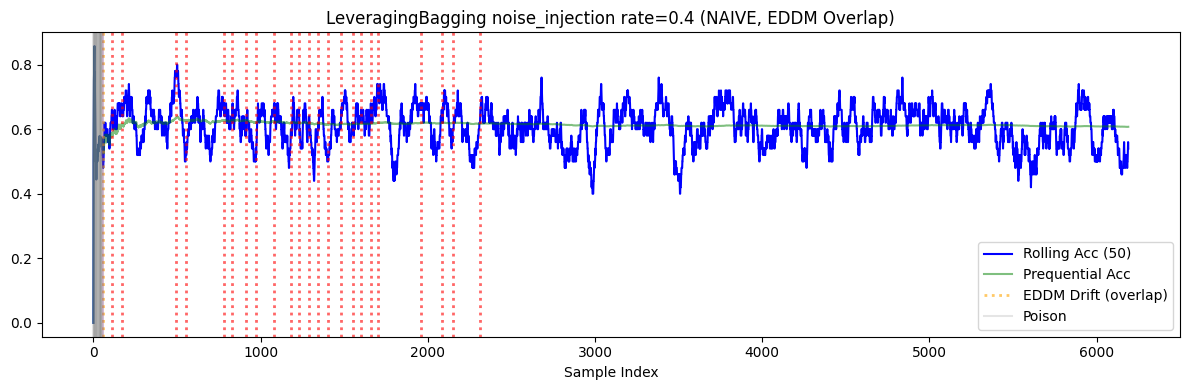

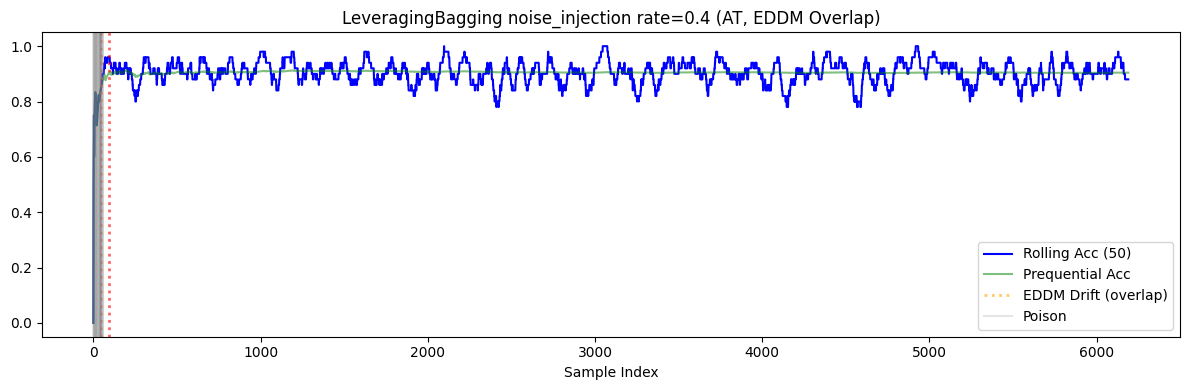

In [18]:
import ast
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def safe_parse_list(s):
    import re
    if type(s) is list:
        return s
    if not isinstance(s, str): return list(s)
    s = re.sub(r'np\.int\d+\((\d+)\)', r'\1', s)
    s = s.replace('\n', ' ').replace('array(', '').replace(')', '')
    try:
        return [int(x.strip()) for x in s.strip('[]').split(',') if x.strip()]
    except Exception:
        import ast; return ast.literal_eval(s)

def plot_temporal_drift_overlap(y_true, y_pred, drift_points, poison_indices, dmethod, title=""):
    correct = [int(yt == yp) for yt, yp in zip(y_true, y_pred)]
    rolling = pd.Series(correct).rolling(50, min_periods=1).mean()
    preq = np.cumsum(correct) / (np.arange(len(correct)) + 1)
    plt.figure(figsize=(12, 4))
    plt.plot(rolling, label="Rolling Acc (50)", color='blue')
    plt.plot(preq, label="Prequential Acc", color='green', alpha=0.5)
    drifts = drift_points[dmethod]
    overlap_drifts = set(drifts).intersection(poison_indices)
    for ix, idx in enumerate(drifts):
        c = 'red' if idx not in overlap_drifts else 'orange'
        plt.axvline(idx, color=c, alpha=0.6, linestyle=':', lw=2,
                    label=f"{dmethod} Drift{' (overlap)' if idx in overlap_drifts else ''}" if ix == 0 else None)
    for ix2, idx in enumerate(poison_indices):
        co = 'purple' if idx in overlap_drifts else 'gray'
        plt.axvline(idx, color=co, alpha=0.2, linestyle='-', label="Poison" if ix2==0 else None)
    plt.title(title)
    plt.xlabel("Sample Index")
    plt.legend()
    plt.tight_layout()
    plt.show()

# for each row in your overlap table with at least 1 overlap
for _, row in overlap_df.iterrows():
    # Get all overlaps for this row
    overlaps = [
        row['Naive-EDDM'], row['Naive-DDM'], row['Naive-ADWIN'],
        row['AT-EDDM'], row['AT-DDM'], row['AT-ADWIN']
    ]
    if sum(overlaps) > 0:  # Only consider rows with any overlap
        dataset = 'IoT_2020_b_0.01.csv'  # Customize if needed
        # Find matching run in your main results DataFrame:
        result_row = df_results[
            (df_results['classifier'] == row['Classifier']) &
            (df_results['poison_type'] == row['Attack']) &
            (df_results['rate'] == row['Rate']) &
            (df_results['dataset'] == dataset)
        ].iloc[0]
        # For NAIVE model
        y_true = safe_parse_list(result_row['naive_true'])
        y_pred = safe_parse_list(result_row['naive_pred'])
        drift_points = {
            'EDDM': safe_parse_list(result_row['naive_drift_EDDM']),
            'DDM': safe_parse_list(result_row['naive_drift_DDM']),
            'ADWIN': safe_parse_list(result_row['naive_drift_ADWIN'])
        }
        poisoned_indices = safe_parse_list(result_row['poisoned_indices'])
        for dmethod in ["EDDM", "DDM", "ADWIN"]:
            if len(set(drift_points[dmethod]).intersection(poisoned_indices)) > 0:
                plot_temporal_drift_overlap(
                    y_true, y_pred, drift_points, poisoned_indices, dmethod,
                    title=f"{row['Classifier']} {row['Attack']} rate={row['Rate']} (NAIVE, {dmethod} Overlap)"
                )
        # For ADVTRN model
        y_true_at = safe_parse_list(result_row['at_true'])
        y_pred_at = safe_parse_list(result_row['at_pred'])
        drift_points_at = {
            'EDDM': safe_parse_list(result_row['at_drift_EDDM']),
            'DDM': safe_parse_list(result_row['at_drift_DDM']),
            'ADWIN': safe_parse_list(result_row['at_drift_ADWIN'])
        }
        for dmethod in ["EDDM", "DDM", "ADWIN"]:
            if len(set(drift_points_at[dmethod]).intersection(poisoned_indices)) > 0:
                plot_temporal_drift_overlap(
                    y_true_at, y_pred_at, drift_points_at, poisoned_indices, dmethod,
                    title=f"{row['Classifier']} {row['Attack']} rate={row['Rate']} (AT, {dmethod} Overlap)"
                )